In [1]:
!pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -----------------------------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go

In [6]:
df = pd.read_csv('Unemployment in India.csv')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [7]:
df.shape

(768, 7)

In [8]:
df.columns.tolist()

['Region',
 ' Date',
 ' Frequency',
 ' Estimated Unemployment Rate (%)',
 ' Estimated Employed',
 ' Estimated Labour Participation Rate (%)',
 'Area']

In [9]:
df.dtypes

Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

In [10]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [11]:
df.columns = df.columns.str.strip()

In [12]:
df.rename(columns = {
    'Region' : 'State',
    'Date' : 'Date',
    'Frequency' : 'Frequency',
    'Estimated Unemployment Rate (%)' : 'Unemployment_Rate',
    'Estimated Employed' : 'Employed',
    'Estimated Labour Participation Rate (%)' : 'Labour_Participation_Rate',
},inplace = True)

df['Date'] = pd.to_datetime(df['Date'].str.strip(),dayfirst = True)

df.head()

,State,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [13]:
df.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


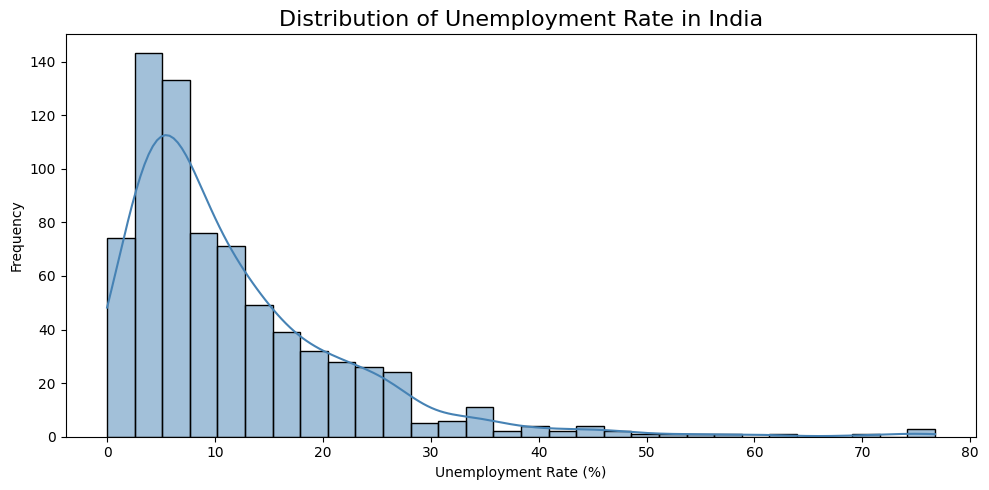

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Unemployment_Rate'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Unemployment Rate in India', fontsize=16)
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

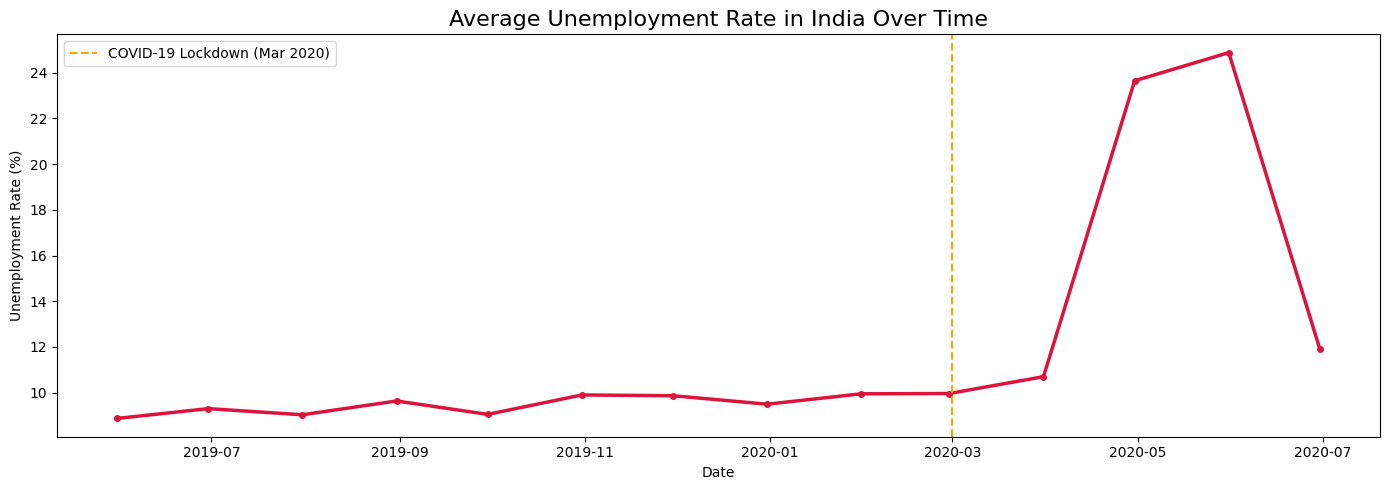

In [15]:
time_df = df.groupby('Date')['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(time_df['Date'], time_df['Unemployment_Rate'], color='crimson', linewidth=2.5, marker='o', markersize=4)
plt.axvline(pd.Timestamp('2020-03-01'), color='orange', linestyle='--', label='COVID-19 Lockdown (Mar 2020)')
plt.title('Average Unemployment Rate in India Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\joshi\AppData\Local\Temp\ipykernel_70228\1501567349.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_df, x='Unemployment_Rate', y='State', palette='Reds_r')


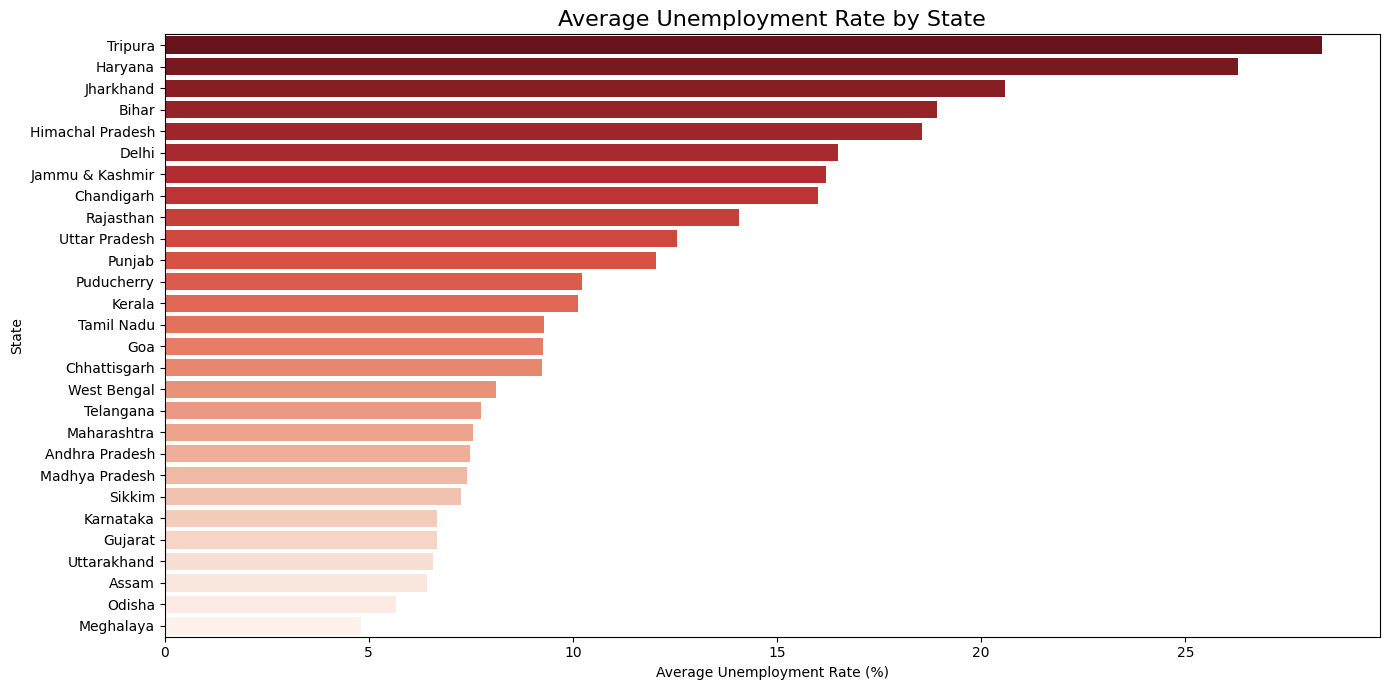

In [16]:
state_df = df.groupby('State')['Unemployment_Rate'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=state_df, x='Unemployment_Rate', y='State', palette='Reds_r')
plt.title('Average Unemployment Rate by State', fontsize=16)
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

C:\Users\joshi\AppData\Local\Temp\ipykernel_70228\2941354842.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5, x='Unemployment_Rate', y='State', palette='Reds', ax=axes[0])
C:\Users\joshi\AppData\Local\Temp\ipykernel_70228\2941354842.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom5, x='Unemployment_Rate', y='State', palette='Greens', ax=axes[1])


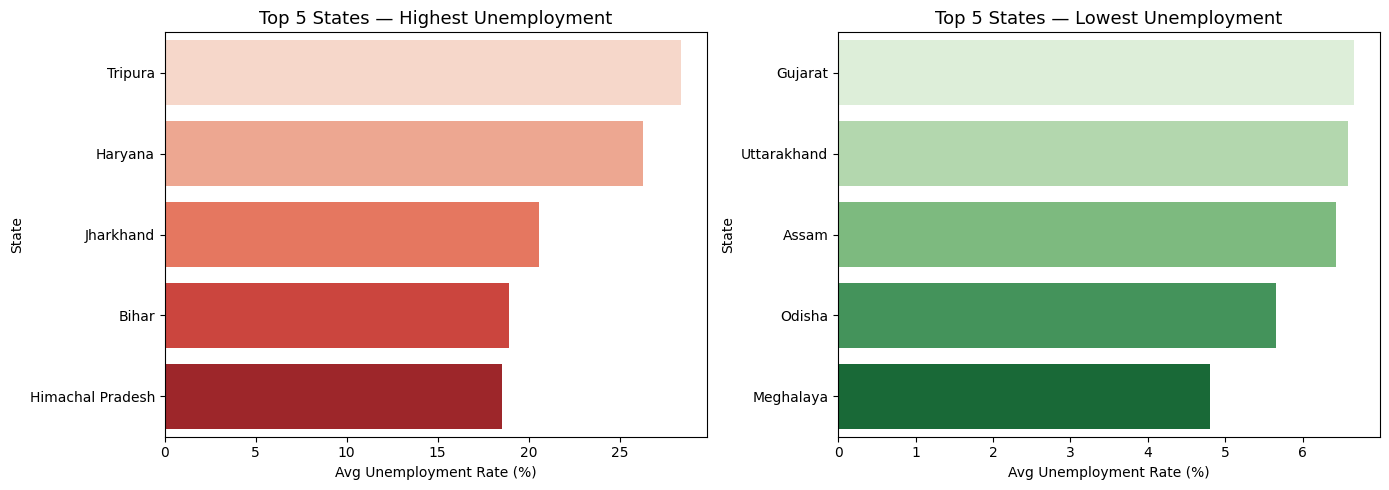

In [17]:
top5 = state_df.head(5)
bottom5 = state_df.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=top5, x='Unemployment_Rate', y='State', palette='Reds', ax=axes[0])
axes[0].set_title('Top 5 States — Highest Unemployment', fontsize=13)
axes[0].set_xlabel('Avg Unemployment Rate (%)')

sns.barplot(data=bottom5, x='Unemployment_Rate', y='State', palette='Greens', ax=axes[1])
axes[1].set_title('Top 5 States — Lowest Unemployment', fontsize=13)
axes[1].set_xlabel('Avg Unemployment Rate (%)')

plt.tight_layout()
plt.show()

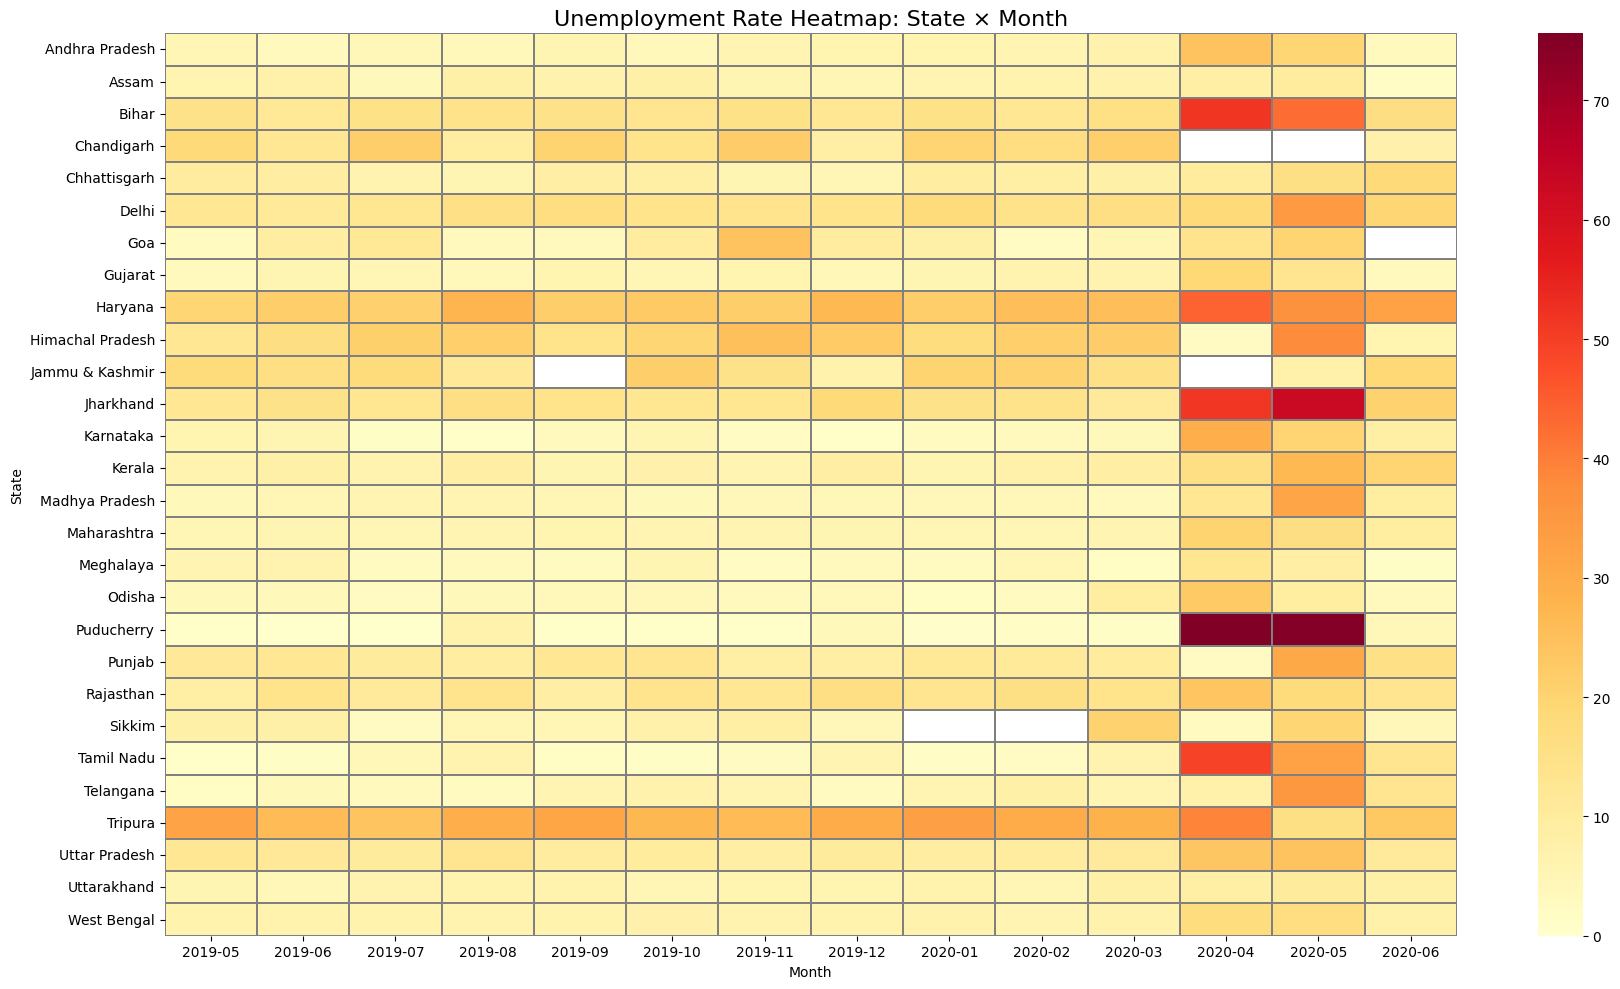

In [18]:
df['Month_Year'] = df['Date'].dt.to_period('M').astype(str)

pivot = df.pivot_table(values='Unemployment_Rate', index='State', columns='Month_Year', aggfunc='mean')

plt.figure(figsize=(18, 10))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, linecolor='grey', annot=False)
plt.title('Unemployment Rate Heatmap: State × Month', fontsize=16)
plt.xlabel('Month')
plt.ylabel('State')
plt.tight_layout()
plt.show()

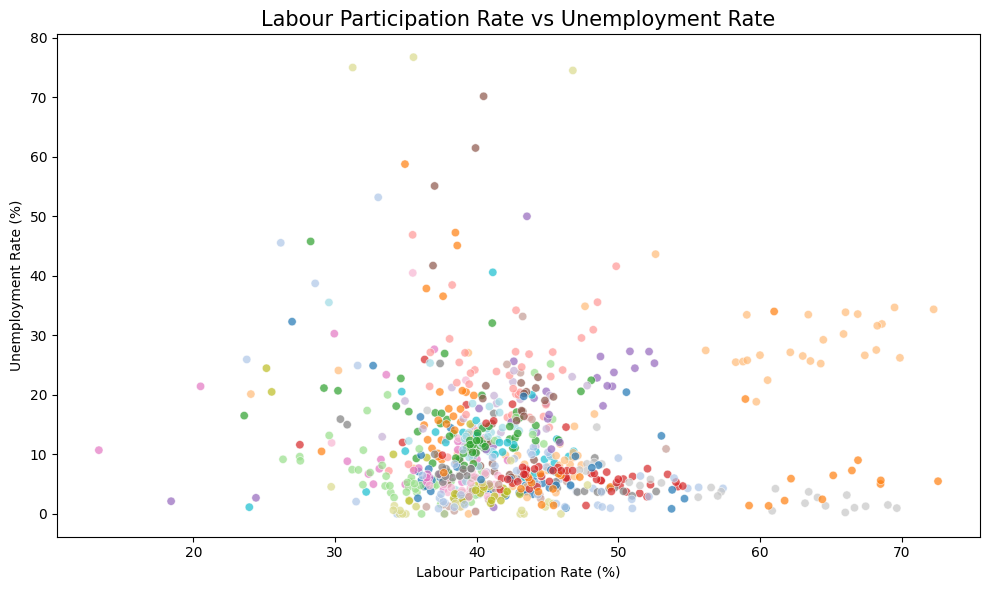

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Labour_Participation_Rate', y='Unemployment_Rate',
                hue='State', legend=False, alpha=0.7, palette='tab20')
plt.title('Labour Participation Rate vs Unemployment Rate', fontsize=15)
plt.xlabel('Labour Participation Rate (%)')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

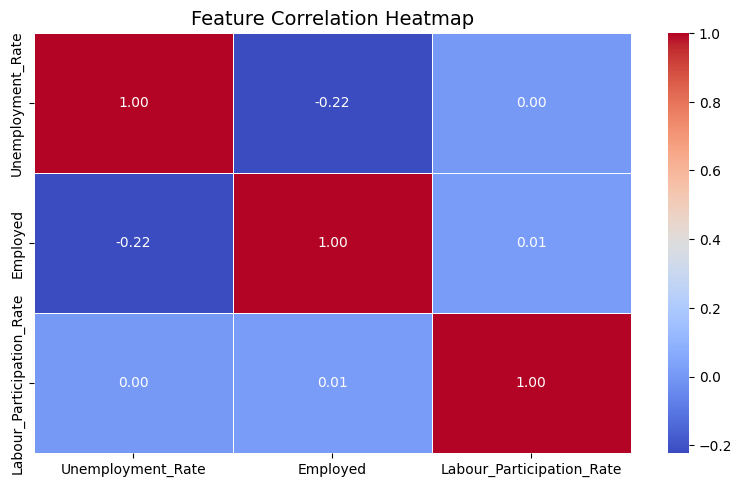

In [20]:
plt.figure(figsize=(8, 5))
corr = df[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\joshi\AppData\Local\Temp\ipykernel_70228\3470434557.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Period', y='Unemployment_Rate', palette={'Pre-COVID': 'steelblue', 'Post-COVID (2020)': 'crimson'})


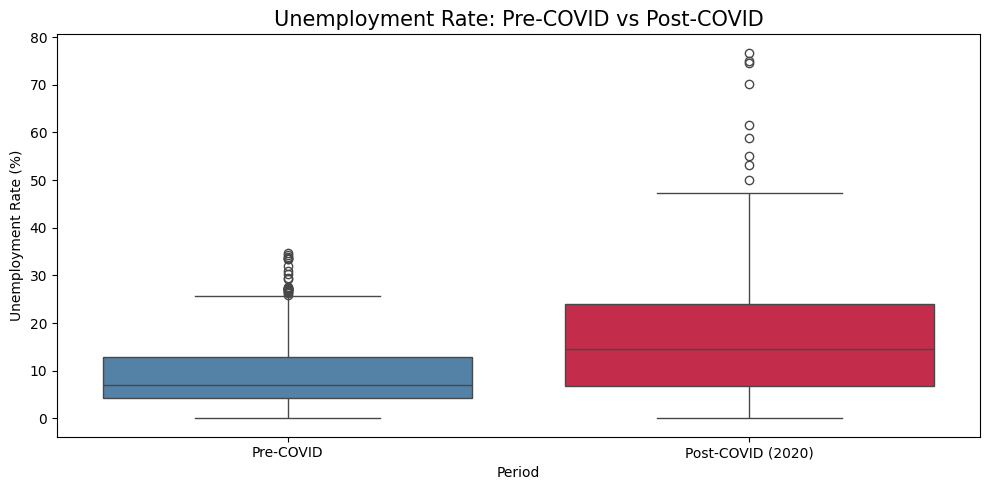

In [21]:
df['Period'] = df['Date'].apply(lambda x: 'Post-COVID (2020)' if x >= pd.Timestamp('2020-03-01') else 'Pre-COVID')

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Period', y='Unemployment_Rate', palette={'Pre-COVID': 'steelblue', 'Post-COVID (2020)': 'crimson'})
plt.title('Unemployment Rate: Pre-COVID vs Post-COVID', fontsize=15)
plt.xlabel('Period')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()